正在量化用户不同使用习惯
基准续航 (Baseline): 17.33 h


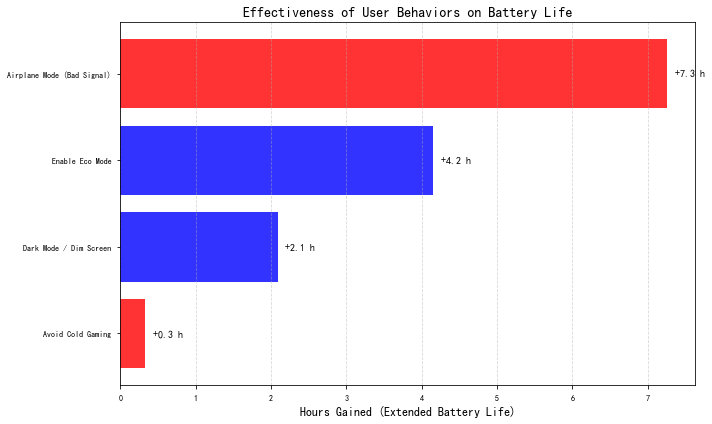


用户行为节能效果排行榜:
                       Action  Gain_Hours                Type
2           Avoid Cold Gaming    0.331667     Critical Safety
1      Dark Mode / Dim Screen    2.085833  Daily Optimization
0             Enable Eco Mode    4.151667  Daily Optimization
3  Airplane Mode (Bad Signal)    7.262222  Situation Handling


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


plt.style.use('seaborn-paper')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False 

# 1. 基础物理模型 

class BatteryConfig:
    def __init__(self, soh=1.0, env_temp=25.0):
        # 电池规格 (Table 1)
        self.Q_rated_mAh = 4500.0
        self.Q_rated_Ah = self.Q_rated_mAh / 1000.0
        self.V_cutoff = 3.0
        self.V_nom = 3.85
        self.soh = soh
        self.Q_actual = self.Q_rated_Ah * self.soh
        
        # 内阻模型 (Table 1 & Physics)
        self.R_internal_base = 0.040 * (1 + 2.0 * (1 - self.soh)) 
        self.R_polarization = 0.010
        self.C_polarization = 500.0
        
        # 热力学参数 (Table 3)
        self.mass = 0.20
        self.Cp = 900.0
        self.h_conv = 8.0
        self.area = 0.02
        self.T_amb = env_temp

    def get_ocv(self, soc):
        return 3.0 + 1.2 * soc - 0.6 * (soc**2) + 0.8 * (soc**3) - 0.1 * (soc**4)

    def get_resistance(self, soc, temp_c):
        temp_k = temp_c + 273.15
        ref_k = 25.0 + 273.15
        beta = 2000.0 
        temp_factor = np.exp(beta * (1/temp_k - 1/ref_k))
        soc_factor = 1.0 + 0.5 * np.exp(-10 * soc)
        return (self.R_internal_base + self.R_polarization) * temp_factor * soc_factor


# 2. 仿真

class BatterySimulator:
    def __init__(self, config):
        self.cfg = config
        self.dt = 1.0 

    def generate_user_profile(self, duration_hours=72, intensity_factor=1.0, seed=None):
        """生成用户负载曲线 (支持固定种子以控制变量)"""
        if seed is not None:
            np.random.seed(seed)
            
        steps = int(duration_hours * 3600 / self.dt)
        # 典型功耗状态 (Table 2): Sleep(0.1), Light(1.5), Media(3.0), Heavy(6.0)
        states_power = np.array([0.1, 1.5, 3.0, 6.0]) * intensity_factor
        
        transition_matrix = [
            [0.95, 0.04, 0.01, 0.00], 
            [0.10, 0.80, 0.08, 0.02], 
            [0.05, 0.15, 0.75, 0.05], 
            [0.01, 0.10, 0.20, 0.69]  
        ]
        
        power_profile = np.zeros(steps)
        current_state = 1
        seg_len = 60 
        n_segments = steps // seg_len
        
        for i in range(n_segments):
            base = states_power[current_state]
            noise = np.random.normal(0, 0.1 * base, seg_len)
            power_profile[i*seg_len : (i+1)*seg_len] = np.maximum(0.01, base + noise)
            current_state = np.random.choice([0, 1, 2, 3], p=transition_matrix[current_state])
            
        return power_profile

    def solve_current(self, P_load, V_ocv, V_p, R_total):
        V_eff = V_ocv - V_p
        delta = V_eff**2 - 4 * R_total * P_load
        if delta < 0: return None
        return (V_eff - np.sqrt(delta)) / (2 * R_total)

    def run_simulation(self, initial_soc=1.0, power_intensity=1.0, fixed_seed=None):
        soc = initial_soc
        V_p = 0.0
        T = self.cfg.T_amb
        
        power_trace = self.generate_user_profile(duration_hours=72, intensity_factor=power_intensity, seed=fixed_seed)
        steps = len(power_trace)
        
        duration_hours = 0.0
        reason = "Time Limit"
        
        for t in range(steps):
            P_load = power_trace[t]
            R_total = self.cfg.get_resistance(soc, T)
            V_ocv = self.cfg.get_ocv(soc)
            I = self.solve_current(P_load, V_ocv, V_p, R_total)
            
            if I is None: 
                duration_hours = t / 3600.0
                reason = "Voltage Collapse"
                break
            
            V_term = V_ocv - V_p - I * R_total
            
            if soc <= 0.0:
                duration_hours = t / 3600.0
                reason = "SOC Depleted"
                break
            if V_term <= self.cfg.V_cutoff:
                duration_hours = t / 3600.0
                reason = "Low Voltage"
                break
                
            d_soc = -I / (self.cfg.Q_actual * 3600.0)
            d_vp = (I/self.cfg.C_polarization) - (V_p/(self.cfg.R_polarization*self.cfg.C_polarization))
            d_temp = (I**2*R_total - self.cfg.h_conv*self.cfg.area*(T-self.cfg.T_amb)) / (self.cfg.mass * self.cfg.Cp)
            
            soc += d_soc * self.dt
            V_p += d_vp * self.dt
            T += d_temp * self.dt
            
        return duration_hours, reason


# 3. 用户行为评估逻辑 

def evaluate_user_behaviors_fixed():
    print("正在量化用户不同使用习惯")
    
    # 设定固定种子
    COMMON_SEED = 2026 
    
    # 1. 建立基准
    base_cfg = BatteryConfig(soh=1.0, env_temp=25.0)
    base_sim = BatterySimulator(base_cfg)
    base_tte, _ = base_sim.run_simulation(initial_soc=1.0, power_intensity=1.0, fixed_seed=COMMON_SEED)
    print(f"基准续航 (Baseline): {base_tte:.2f} h")
    
    results = []
    
    # 策略 A: 开启省电模式 
  
    tte_eco, _ = BatterySimulator(BatteryConfig(env_temp=25)).run_simulation(power_intensity=0.7, fixed_seed=COMMON_SEED)
    results.append({
        'Action': 'Enable Eco Mode', 
        'Gain_Hours': tte_eco - base_tte, 
        'Type': 'Daily Optimization'
    })
    
    # 策略 B: 深色模式/自动亮度 
   
    tte_dark, _ = BatterySimulator(BatteryConfig(env_temp=25)).run_simulation(power_intensity=0.85, fixed_seed=COMMON_SEED)
    results.append({
        'Action': 'Dark Mode / Dim Screen', 
        'Gain_Hours': tte_dark - base_tte, 
        'Type': 'Daily Optimization'
    })
    
    # 策略 C: 避免低温游戏 

    tte_cold, _ = BatterySimulator(BatteryConfig(env_temp=0)).run_simulation(power_intensity=1.5, fixed_seed=COMMON_SEED)
    tte_warm, _ = BatterySimulator(BatteryConfig(env_temp=25)).run_simulation(power_intensity=1.5, fixed_seed=COMMON_SEED)
    results.append({
        'Action': 'Avoid Cold Gaming', 
        'Gain_Hours': tte_warm - tte_cold, 
        'Type': 'Critical Safety'
    })
    
    # 策略 D: 信号不佳开启飞行模式 

    tte_bad_signal, _ = BatterySimulator(BatteryConfig(env_temp=25)).run_simulation(power_intensity=2.0, fixed_seed=COMMON_SEED)
    tte_airplane, _ = BatterySimulator(BatteryConfig(env_temp=25)).run_simulation(power_intensity=1.0, fixed_seed=COMMON_SEED)
    results.append({
        'Action': 'Airplane Mode (Bad Signal)', 
        'Gain_Hours': tte_airplane - tte_bad_signal, 
        'Type': 'Situation Handling'
    })

   
    df_res = pd.DataFrame(results).sort_values('Gain_Hours', ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = ['blue' if t == 'Daily Optimization' else 'red' for t in df_res['Type']]
    # 修改color变量内容 如：blue、pink、red、yellow、green、purple、gold等
    bars = plt.barh(df_res['Action'], df_res['Gain_Hours'], color=colors, alpha=0.8)
    
    plt.xlabel('Hours Gained (Extended Battery Life)', fontsize=12)
    plt.title('Effectiveness of User Behaviors on Battery Life', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'+{width:.1f} h', va='center', fontsize=10, fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    
    return df_res

# 运行代码
df_user_actions = evaluate_user_behaviors_fixed()
print("\n用户行为节能效果排行榜:")
print(df_user_actions)

正在评估 OS 智能电源管理策略 (场景: 7W 高负载 @ 5°C)...
[标准模式] 坚持时间: 0.1 min, 关机原因: Low Voltage Cutoff
[智能模式] 坚持时间: 30.0 min, 关机原因: Finished


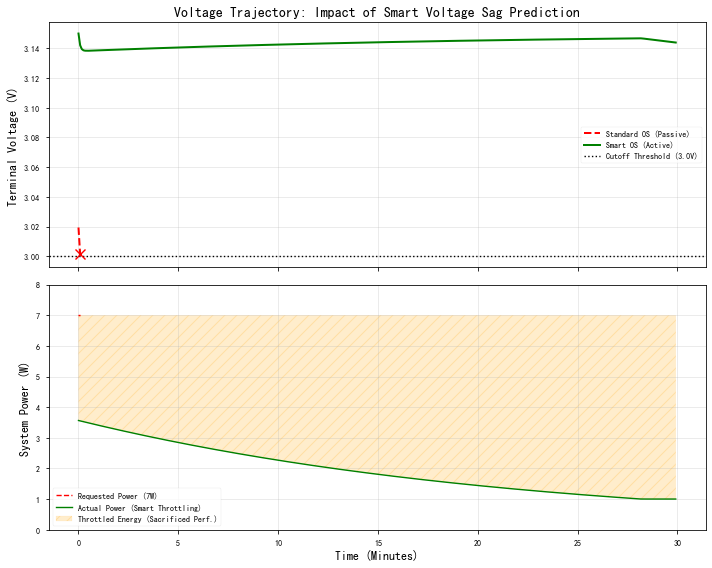

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


plt.style.use('seaborn-paper')
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 

class BatteryConfig:

    def __init__(self, soh=1.0, env_temp=25.0):
        # --- 电池物理参数 ---
        self.Q_rated_mAh = 4500.0   
        self.Q_rated_Ah = self.Q_rated_mAh / 1000.0
        self.V_cutoff = 3.0         # 截止电压
        
        # SOH 修正
        self.soh = soh
        self.Q_actual = self.Q_rated_Ah * self.soh
        
        # 内阻模型 (基准 40mOhm)
        self.R_internal_base = 0.040 * (1 + 2.0 * (1 - self.soh)) 
        self.R_polarization = 0.010
        self.C_polarization = 500.0
        
        # 热力学参数
        self.mass = 0.20            
        self.Cp = 900.0             
        self.h_conv = 8.0           
        self.area = 0.02            
        self.T_amb = env_temp

    def get_ocv(self, soc):
        return 3.0 + 1.2 * soc - 0.6 * (soc**2) + 0.8 * (soc**3) - 0.1 * (soc**4)

    def get_resistance(self, soc, temp_c):
        # Arrhenius 温度模型 + 低电量修正
        temp_k = temp_c + 273.15
        ref_k = 25.0 + 273.15
        beta = 2000.0 
        temp_factor = np.exp(beta * (1/temp_k - 1/ref_k))
        soc_factor = 1.0 + 0.6 * np.exp(-12 * soc)
        return (self.R_internal_base + self.R_polarization) * temp_factor * soc_factor

class SmartBatterySimulator:

    def __init__(self, config):
        self.cfg = config
        self.dt = 1.0 

    def solve_current(self, P_load, V_ocv, V_p, R_total):
        # 求解 I * (V_ocv - V_p - I*R) = P
        V_eff = V_ocv - V_p
        delta = V_eff**2 - 4 * R_total * P_load
        if delta < 0: return None
        return (V_eff - np.sqrt(delta)) / (2 * R_total)

    def run_smart_simulation(self, initial_soc=0.25, enable_protection=False):
        """
        模拟极端场景：
        1. 初始电量低 (25%)
        2. 环境冷 (5°C)
        3. 负载重 (7W)
        """
        soc = initial_soc
        V_p = 0.0
        T = self.cfg.T_amb
        
        # 设定目标：用户玩 30 分钟游戏
        steps = int(30 * 60 / self.dt)
        
        # 用户请求的功率 
        target_power = 7.0 
        
        history = {'time_min': [], 'voltage': [], 'power': [], 'throttled': []}
        reason = "Finished"
        
        for t in range(steps):
       
            if enable_protection:
                # 1. 感知: OS 实时估算当前内阻 
                R_est = self.cfg.get_resistance(soc, T)
                
                # 2. 预测: 计算当前状态下的最大安全电流 
 
                V_ocv_now = self.cfg.get_ocv(soc)
                I_limit = (V_ocv_now - self.cfg.V_cutoff - 0.15) / R_est
                
                # 3. 决策: 计算对应的最大安全功率 

                P_limit = I_limit * (self.cfg.V_cutoff + 0.15)
                
                # 4. 执行: 削峰 
                if target_power > P_limit:
                    # 强制将功率限制在 P_limit
                    P_actual = max(1.0, P_limit) 
                    is_throttled = 1
                else:
                    P_actual = target_power
                    is_throttled = 0
            else:
                # 标准模式
                P_actual = target_power
                is_throttled = 0
            
            # --- 物理响应 ---
            R_total = self.cfg.get_resistance(soc, T)
            V_ocv = self.cfg.get_ocv(soc)
            I = self.solve_current(P_actual, V_ocv, V_p, R_total)
            
            # 电压崩溃判定 
            if I is None:
                reason = "Voltage Collapse"
                break
            
            V_term = V_ocv - V_p - I * R_total
            
 
            if t % 5 == 0:
                history['time_min'].append(t/60.0)
                history['voltage'].append(V_term)
                history['power'].append(P_actual)
                history['throttled'].append(is_throttled)
            
            # 关机判定 
            if V_term <= self.cfg.V_cutoff:
                reason = "Low Voltage Cutoff"
                break
            if soc <= 0:
                reason = "SOC Empty"
                break
                
   
            d_soc = -I / (self.cfg.Q_actual * 3600.0)
            d_vp = (I/self.cfg.C_polarization) - (V_p/(self.cfg.R_polarization*self.cfg.C_polarization))
            d_temp = (I**2*R_total - self.cfg.h_conv*self.cfg.area*(T-self.cfg.T_amb)) / (self.cfg.mass * self.cfg.Cp)
            
            soc += d_soc * self.dt
            V_p += d_vp * self.dt
            T += d_temp * self.dt
            
        return pd.DataFrame(history), t/60.0, reason

def evaluate_os_strategy_with_data():
    print("正在评估 OS 智能电源管理策略 (场景: 7W 高负载 @ 5°C)...")
    
    # 场景设定: 老化电池 (SOH=0.8), 低温 (5°C)
    cfg = BatteryConfig(soh=0.8, env_temp=5.0)
    sim = SmartBatterySimulator(cfg)
    
    # 1. 运行标准模式 
    trace_std, tte_std, reason_std = sim.run_smart_simulation(enable_protection=False)
    print(f"[标准模式] 坚持时间: {tte_std:.1f} min, 关机原因: {reason_std}")
    
    # 2. 运行智能模式 
    trace_smart, tte_smart, reason_smart = sim.run_smart_simulation(enable_protection=True)
    print(f"[智能模式] 坚持时间: {tte_smart:.1f} min, 关机原因: {reason_smart}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # 图1: 电压曲线
    ax1.plot(trace_std['time_min'], trace_std['voltage'], 'r--', linewidth=2, label='Standard OS (Passive)')
    ax1.plot(trace_smart['time_min'], trace_smart['voltage'], 'g-', linewidth=2, label='Smart OS (Active)')
    ax1.axhline(3.0, color='k', linestyle=':', label='Cutoff Threshold (3.0V)')
    

    if len(trace_std) > 0 and reason_std != "Finished":
        fail_time = trace_std['time_min'].iloc[-1]
        fail_volt = trace_std['voltage'].iloc[-1]
        ax1.scatter(fail_time, fail_volt, color='red', s=100, marker='x', zorder=5)
         # 修改color变量内容 如：blue、pink、red、yellow、green、purple、gold等
       
        
    
    ax1.set_ylabel('Terminal Voltage (V)', fontsize=12)
    ax1.set_title('Voltage Trajectory: Impact of Smart Voltage Sag Prediction', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 图2: 功率曲线
    ax2.plot(trace_std['time_min'], trace_std['power'], 'r--', label='Requested Power (7W)')
    ax2.plot(trace_smart['time_min'], trace_smart['power'], 'g-', label='Actual Power (Smart Throttling)')
    
    # 填充削峰区域
    ax2.fill_between(trace_smart['time_min'], trace_smart['power'], 7.0, 
                     where=(trace_smart['throttled']==1),
                     color='orange', alpha=0.2, hatch='//', label='Throttled Energy (Sacrificed Perf.)')
     # 修改color变量内容 如：blue、pink、red、yellow、green、purple、gold等
    ax2.set_ylabel('System Power (W)', fontsize=12)
    ax2.set_xlabel('Time (Minutes)', fontsize=12)
    ax2.set_ylim(0, 8.0)
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 运行评估
evaluate_os_strategy_with_data()